In [ ]:
!nvidia-smi

Sun Dec 14 17:39:25 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%pip uninstall -y torch torchvision torchaudio
%pip install torch==2.5.1+cu121 torchvision==0.20.1+cu121 torchaudio==2.5.1+cu121 --extra-index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaudio 2.9.0+cu126
Uninstalling torchaudio-2.9.0+cu126:
  Successfully uninstalled torchaudio-2.9.0+cu126
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 124.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 111.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 109.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 61.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 128.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━

İlk satırda daha önce yüklü **torch** **torchvision** **torchaudio** paketlerini kaldırdım çünkü kodun ilerleyen kısımlarında hata veriyordu sürüm uyuşmazlığı var diye sonra 2. satırda manuel olarak başka versiyonlar kurdum.

In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.5.1+cu121
True


Torch'ların başka sürümlerini kurduktan sonra kontrol ettim kurulmuş mu diye bir sıkıntı var mı?

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


Bu kod çalışma dizinini ```  HOME ``` adlı değişkene atıyor.

In [ ]:
!pip install ultralytics==8.0.196

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.0.196 🚀 Python-3.12.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 45.9/112.6 GB disk)


```
# !pip install ultralytics==8.0.196
```
Bu satırda Ultralytics YOLOv8'i belirli bir sürüm ile kurdum.


```
# from IPython import display
display.clear_output()
```
Önceki hücrelerden kalan çıktıların temizlenmesi için.


```
# import ultralytics
ultralytics.checks()
```

Ultralytics kütüphanesini dahil ettim. ```checks()```  fonksiyonu ile:

- PyTorch sürümü,

- CUDA (GPU) durumu,

- Donanım uyumluluğu

kontrol edildi.


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

```
# from ultralytics import YOLO
```
Ultralytics kütüphanesindeki YOLO dahil edildi.

```
# from IPython.display import display, Image
```

display ve Image fonksiyonları, modelin ürettiği sonuçların notebook ortamında görsel olarak incelenebilmesi için.

In [ ]:
%cd {HOME}
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

/content
100% 6.23M/6.23M [00:00<00:00, 148MB/s]
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py:567: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return to

YOLOv8 modelinin doğru şekilde çalışıp çalışmadığını görmek amacıyla roboflow'dan örnek aldım. İlk satırda ``HOME`` içine girerek çalışma dizinini ayarladım.

- task=detect ile nesne tespiti görevi seçildi

- mode=predict ile eğitim dışı bir tahmin (inference) işlemi yapıldı

- model=yolov8n.pt kullanılarak önceden eğitilmiş YOLOv8 nano modeli yüklendi

- conf=0.25 değeri ile minimum güven eşiği belirlendi

- source parametresi ile internet üzerinden alınan örnek bir görsel kullanıldı.

- save=True parametresi ile çıktı kaydedildi

/content


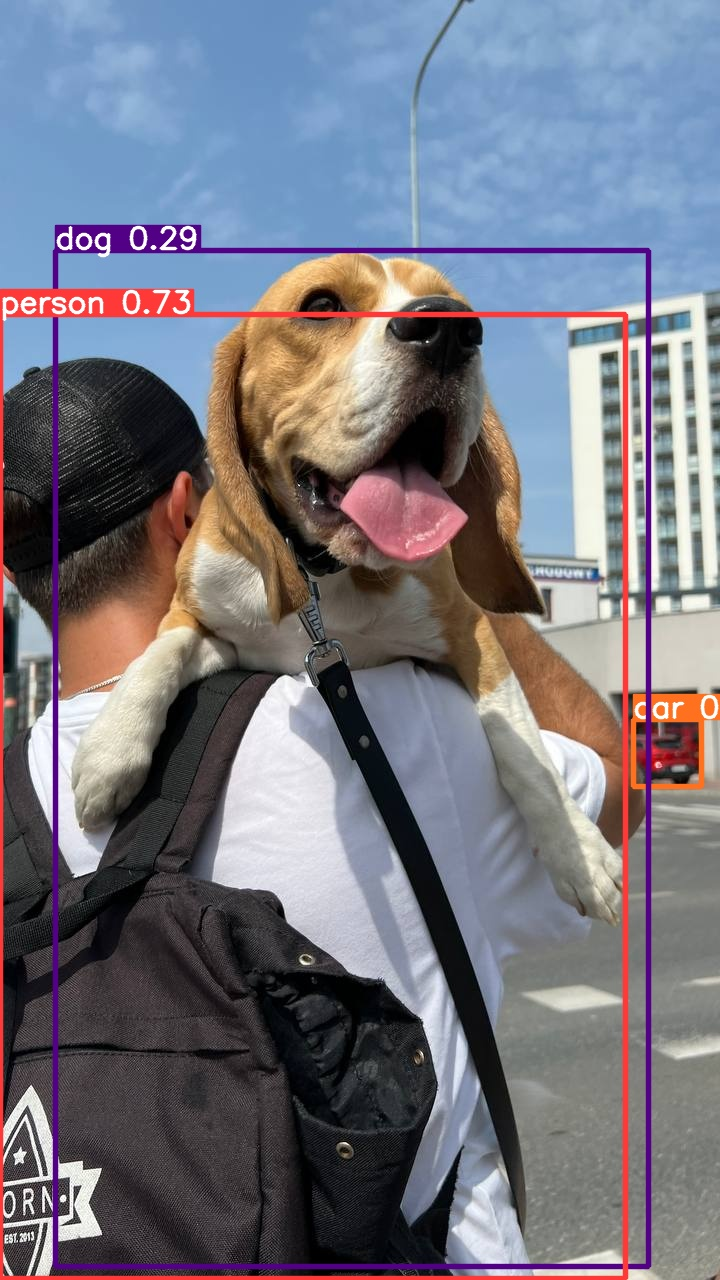

In [ ]:
%cd {HOME}
Image(filename='runs/detect/predict/dog.jpeg', height=600)

runs/detect/predict/ klasörü altında oluşturulan görseli (dog.jpeg) notebook içerisinde görüntüledim.

In [ ]:
!ls /content

dog.jpeg  runs	yoda_odevlendirme_veriseti.yolov8.zip  yolov8n.pt


``content`` dizini altında bulunan dosya ve klasörleri görüntülemek için.

In [ ]:
!unzip yoda_odevlendirme_veriseti.yolov8.zip -d /content/datasets

Archive:  yoda_odevlendirme_veriseti.yolov8.zip
  inflating: /content/datasets/README.dataset.txt  
  inflating: /content/datasets/README.roboflow.txt  
  inflating: /content/datasets/data.yaml  
   creating: /content/datasets/test/
   creating: /content/datasets/test/images/
 extracting: /content/datasets/test/images/24_August_Flight_1_24_August_Flight_1frame_0194_jpg.rf.fab2f9f484944696861f201c9e11433c.jpg  
 extracting: /content/datasets/test/images/24_August_Flight_1_24_August_Flight_1frame_0227_jpg.rf.e30be195d151bae261ed2ca01f3dc25e.jpg  
 extracting: /content/datasets/test/images/24_August_Flight_1_24_August_Flight_1frame_0235_jpg.rf.e50162f6928a2762a2fe31c919b63c48.jpg  
 extracting: /content/datasets/test/images/24_August_Flight_2_frame_0124_jpg.rf.0529e1f349c499fcbb47a263814de6d9.jpg  
 extracting: /content/datasets/test/images/24_August_Flight_2_frame_0171_jpg.rf.f6672672f4558b80d7525e8d246309d5.jpg  
 extracting: /content/datasets/test/images/24_August_Flight_2_frame_0172_j

zip olarak veri setinin collab'a yüklemiştim bunu zip'ten çıkararak datasets klasörüne ekledim.

In [ ]:
!tree /content/datasets -L 3

/bin/bash: line 1: tree: command not found


bu kod veri setinin ``train`` ``valid`` ve `test` bölümlerine ayrılıp ayrılamdığını ve `images` ve `labels` klasörlerinin bulunup bulunmadığı kontrol etmek için ama başlangıçta ``tree`` komutu yüklü olmadığı için çalışmadı.

In [ ]:
!apt-get install -y tree

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (177 kB/s)
Selecting previously unselected package tree.
(Reading database ... 121689 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


``tree`` komutunu yükledim

In [ ]:
!tree /content/datasets -L 3

/content/datasets
├── data.yaml
├── README.dataset.txt
├── README.roboflow.txt
├── test
│   ├── images
│   │   ├── 24_August_Flight_1_24_August_Flight_1frame_0194_jpg.rf.fab2f9f484944696861f201c9e11433c.jpg
│   │   ├── 24_August_Flight_1_24_August_Flight_1frame_0227_jpg.rf.e30be195d151bae261ed2ca01f3dc25e.jpg
│   │   ├── 24_August_Flight_1_24_August_Flight_1frame_0235_jpg.rf.e50162f6928a2762a2fe31c919b63c48.jpg
│   │   ├── 24_August_Flight_2_frame_0124_jpg.rf.0529e1f349c499fcbb47a263814de6d9.jpg
│   │   ├── 24_August_Flight_2_frame_0171_jpg.rf.f6672672f4558b80d7525e8d246309d5.jpg
│   │   ├── 24_August_Flight_2_frame_0172_jpg.rf.0438705934ceb0a63c8d16a9d8369afb.jpg
│   │   ├── 24_August_Flight_2_frame_0178_jpg.rf.81db1ff42157b66e40b3d84e31f88177.jpg
│   │   ├── 24_August_Flight_2_frame_0208_jpg.rf.62d01b3a99cc8226d5f5128e6f436c13.jpg
│   │   ├── 24_August_Flight_2_frame_0218_jpg.rf.7b41eac98ee74d890576a8efb468d42b.jpg
│   │   ├── 24_August_Flight_2_frame_1885_jpg.rf.ac23d755ed7fe166a1bf

``tree`` komutunu yükledikten sonra tekrar çalıştırdım

In [ ]:
!yolo task=detect mode=train model=yolov8s.pt data=/content/datasets/data.yaml epochs=25 imgsz=800

100% 21.5M/21.5M [00:00<00:00, 106MB/s] 
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py:567: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load

Bu komut ile YOLOv8 modeli, hazırlanan veri seti kullanılarak eğitilmiştir.

- task=detect parametresi yapılan görevin nesne tespiti olduğunu belirtiyor.

- mode=train ile model eğitim moduna alındı.

- model=yolov8s.pt ifadesi önceden eğitilmiş YOLOv8 small (s) modelinin başlangıç ağırlıkları olarak kullanıldığını gösteriyor.

- data=/content/datasets/data.yaml parametresi veri setine ait sınıf bilgileri ve eğitim/validasyon yollarını içeren yapılandırma dosyasını belirtiyor.

- epochs=25 değeri ile modelin veri seti üzerinde 25 tur (epoch) eğitilmesi sağlanıyor.

- imgsz=800 parametresi eğitim sırasında kullanılan görüntülerin yeniden boyutlandırılacağı çözünürlüğü ifade ediyor.

In [ ]:
!ls /content/runs/detect/train

args.yaml					    train_batch1020.jpg
confusion_matrix_normalized.png			    train_batch1021.jpg
confusion_matrix.png				    train_batch1022.jpg
events.out.tfevents.1765735082.ee5c6cf36469.5076.0  train_batch1.jpg
F1_curve.png					    train_batch2.jpg
labels_correlogram.jpg				    val_batch0_labels.jpg
labels.jpg					    val_batch0_pred.jpg
P_curve.png					    val_batch1_labels.jpg
PR_curve.png					    val_batch1_pred.jpg
R_curve.png					    val_batch2_labels.jpg
results.csv					    val_batch2_pred.jpg
results.png					    weights
train_batch0.jpg


Bu komutu YOLOv8 eğitimi tamamlandıktan sonra oluşturulan çıktı dosyalarını listelemek için kullandım.

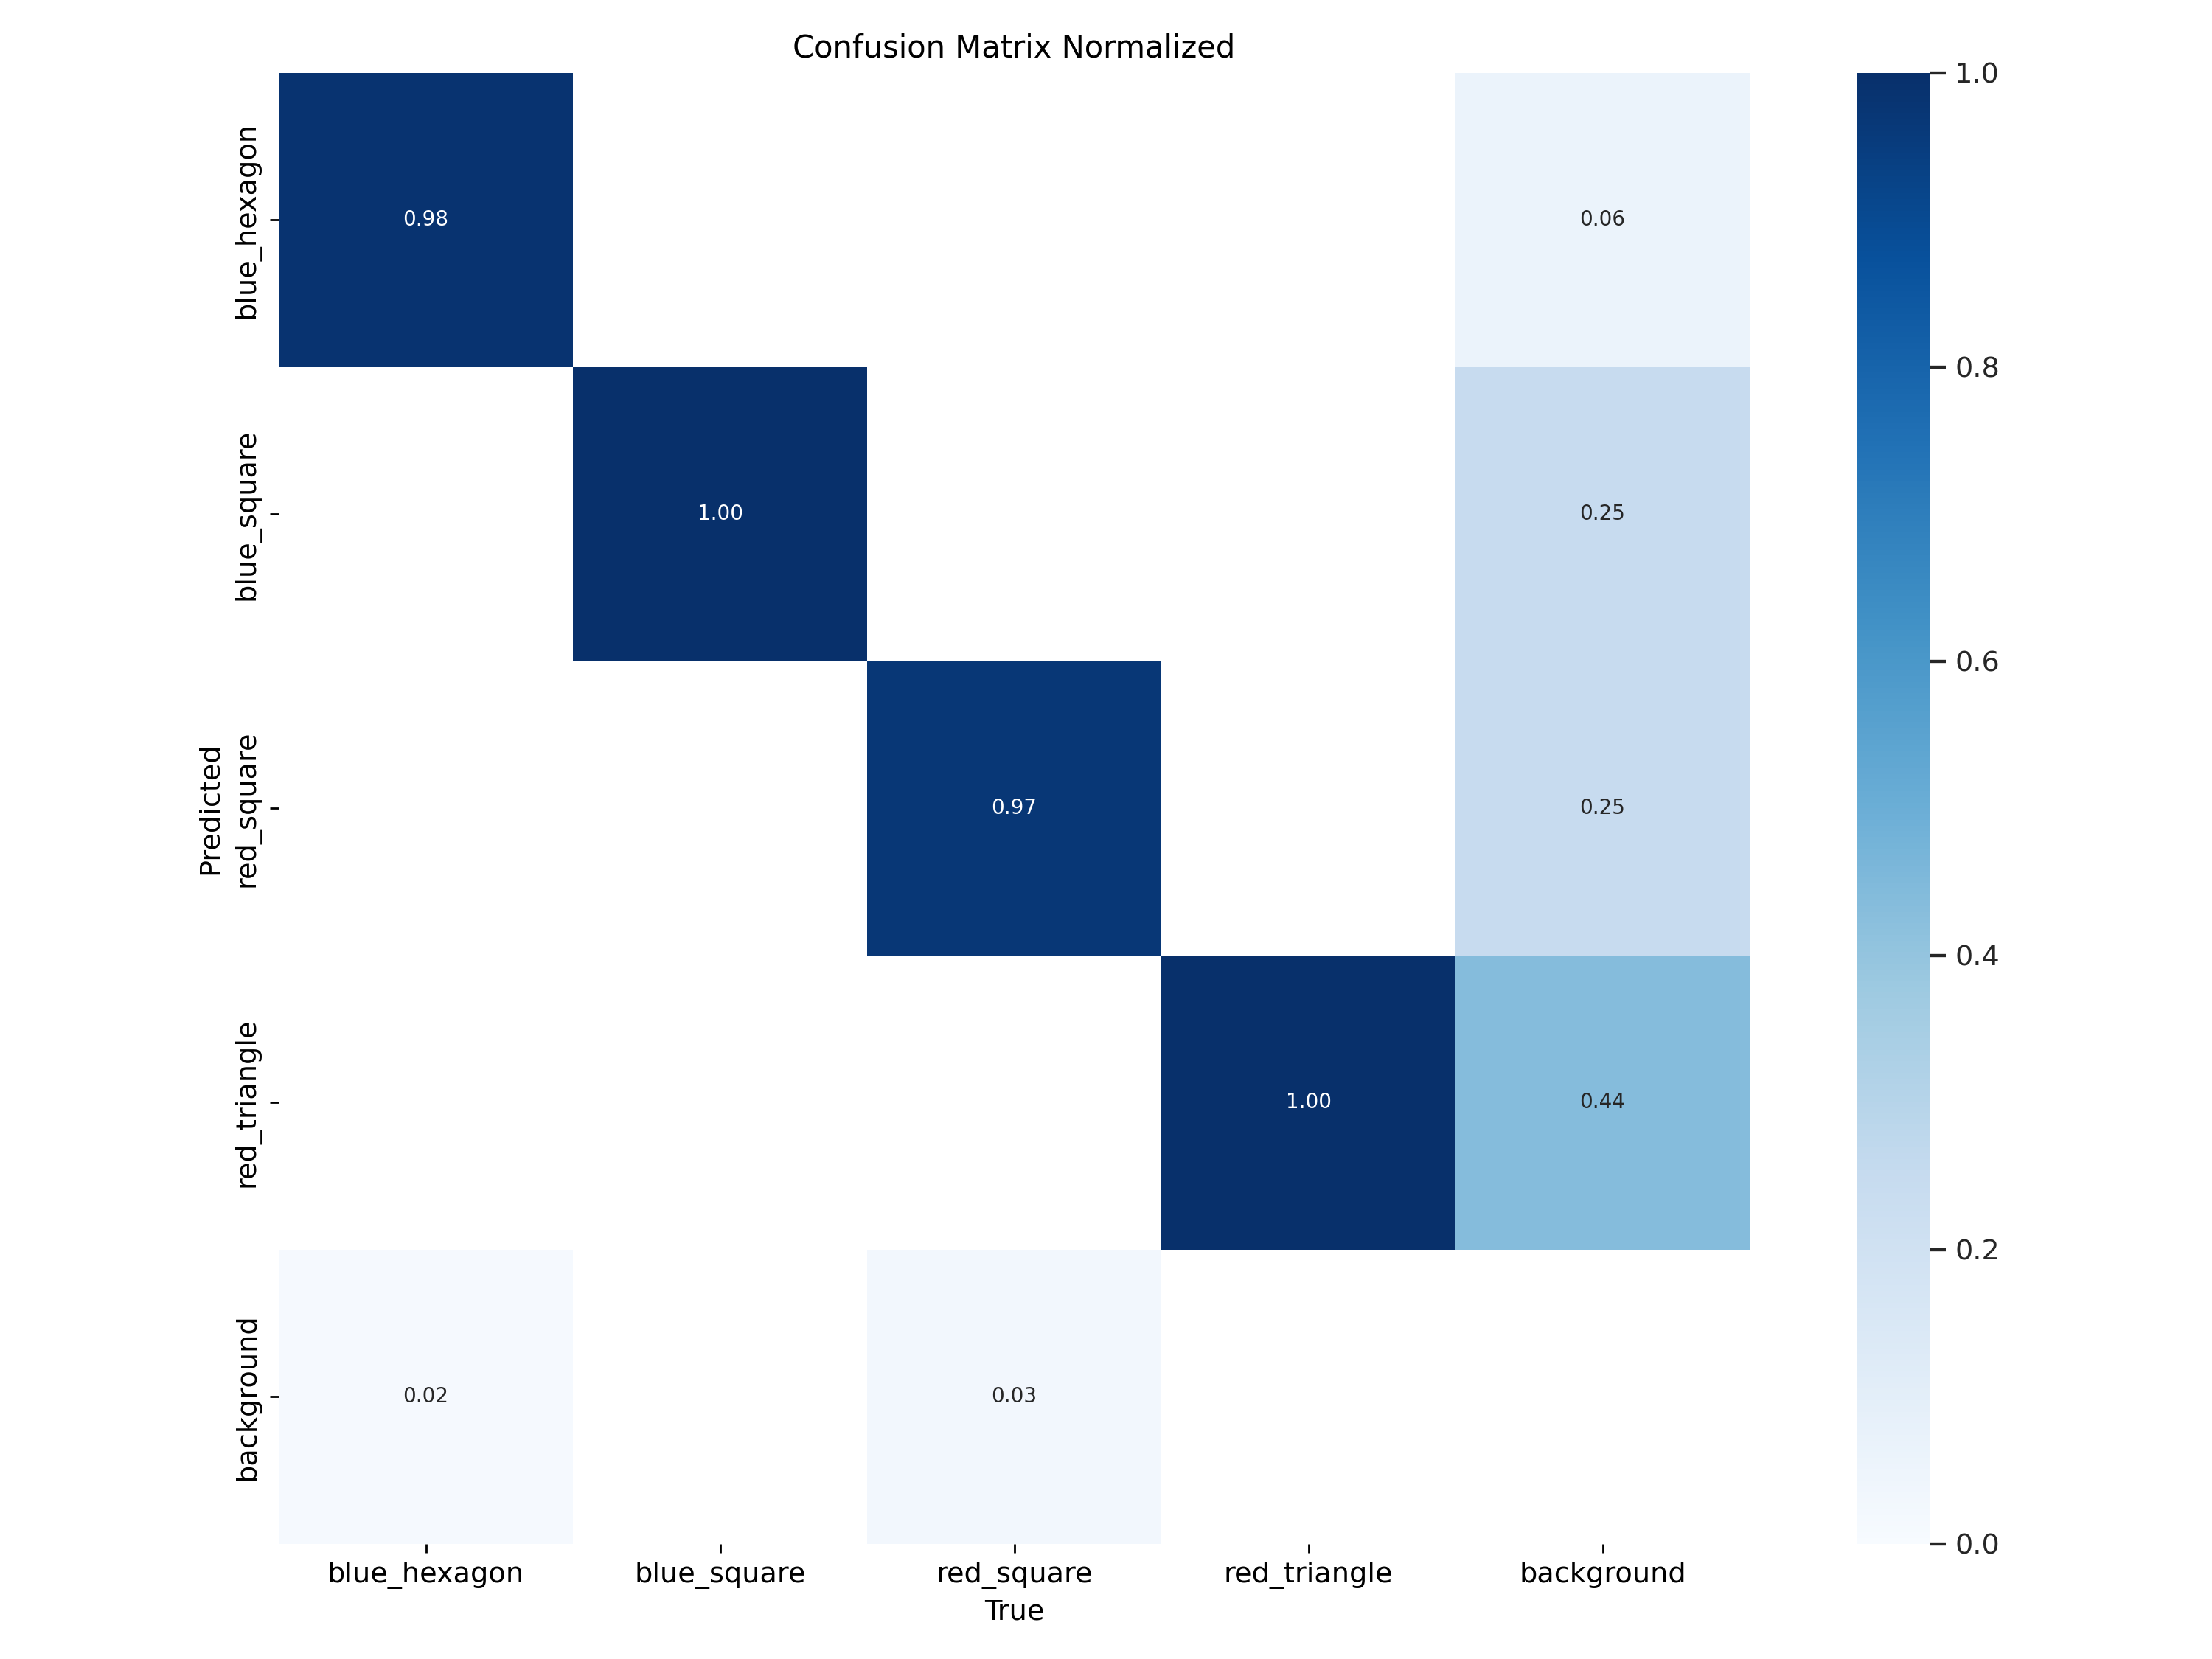

In [ ]:
Image(filename="/content/runs/detect/train/confusion_matrix_normalized.png", width=600)

Bu görsel, eğitilen YOLOv8 modelinin sınıflandırma başarısını normalize edilmiş confusion matrix'i gösteriyor.

Sonuçlarına bakıldığında:

- blue_hexagon sınıfı yüksek doğrulukla tahmin edildi. Diyagonal değeri 1.00  bu sınıfa ait örneklerin tamamına yakınınını doğru tespit etmiş valla helal olsun.

- blue_square ve red_square sınıflarında da yüksek başarı sağladı. Ancak bu sınıflar arasında biraz karıştırdı.

- red_triangle sınıfı genel olarak doğru tahmin edilmiştir fakat bazı örneklerde diğer sınıflarla karışma yaşanmış.

Genel olarak:

- Modelin sınıflar arasında ayırt edici özellikleri büyük ölçüde öğrenmiş.

- Hatalar çoğunlukla şekil veya renk olarak birbirine benzeyen sınıflar arasında gerçekleşmiş.

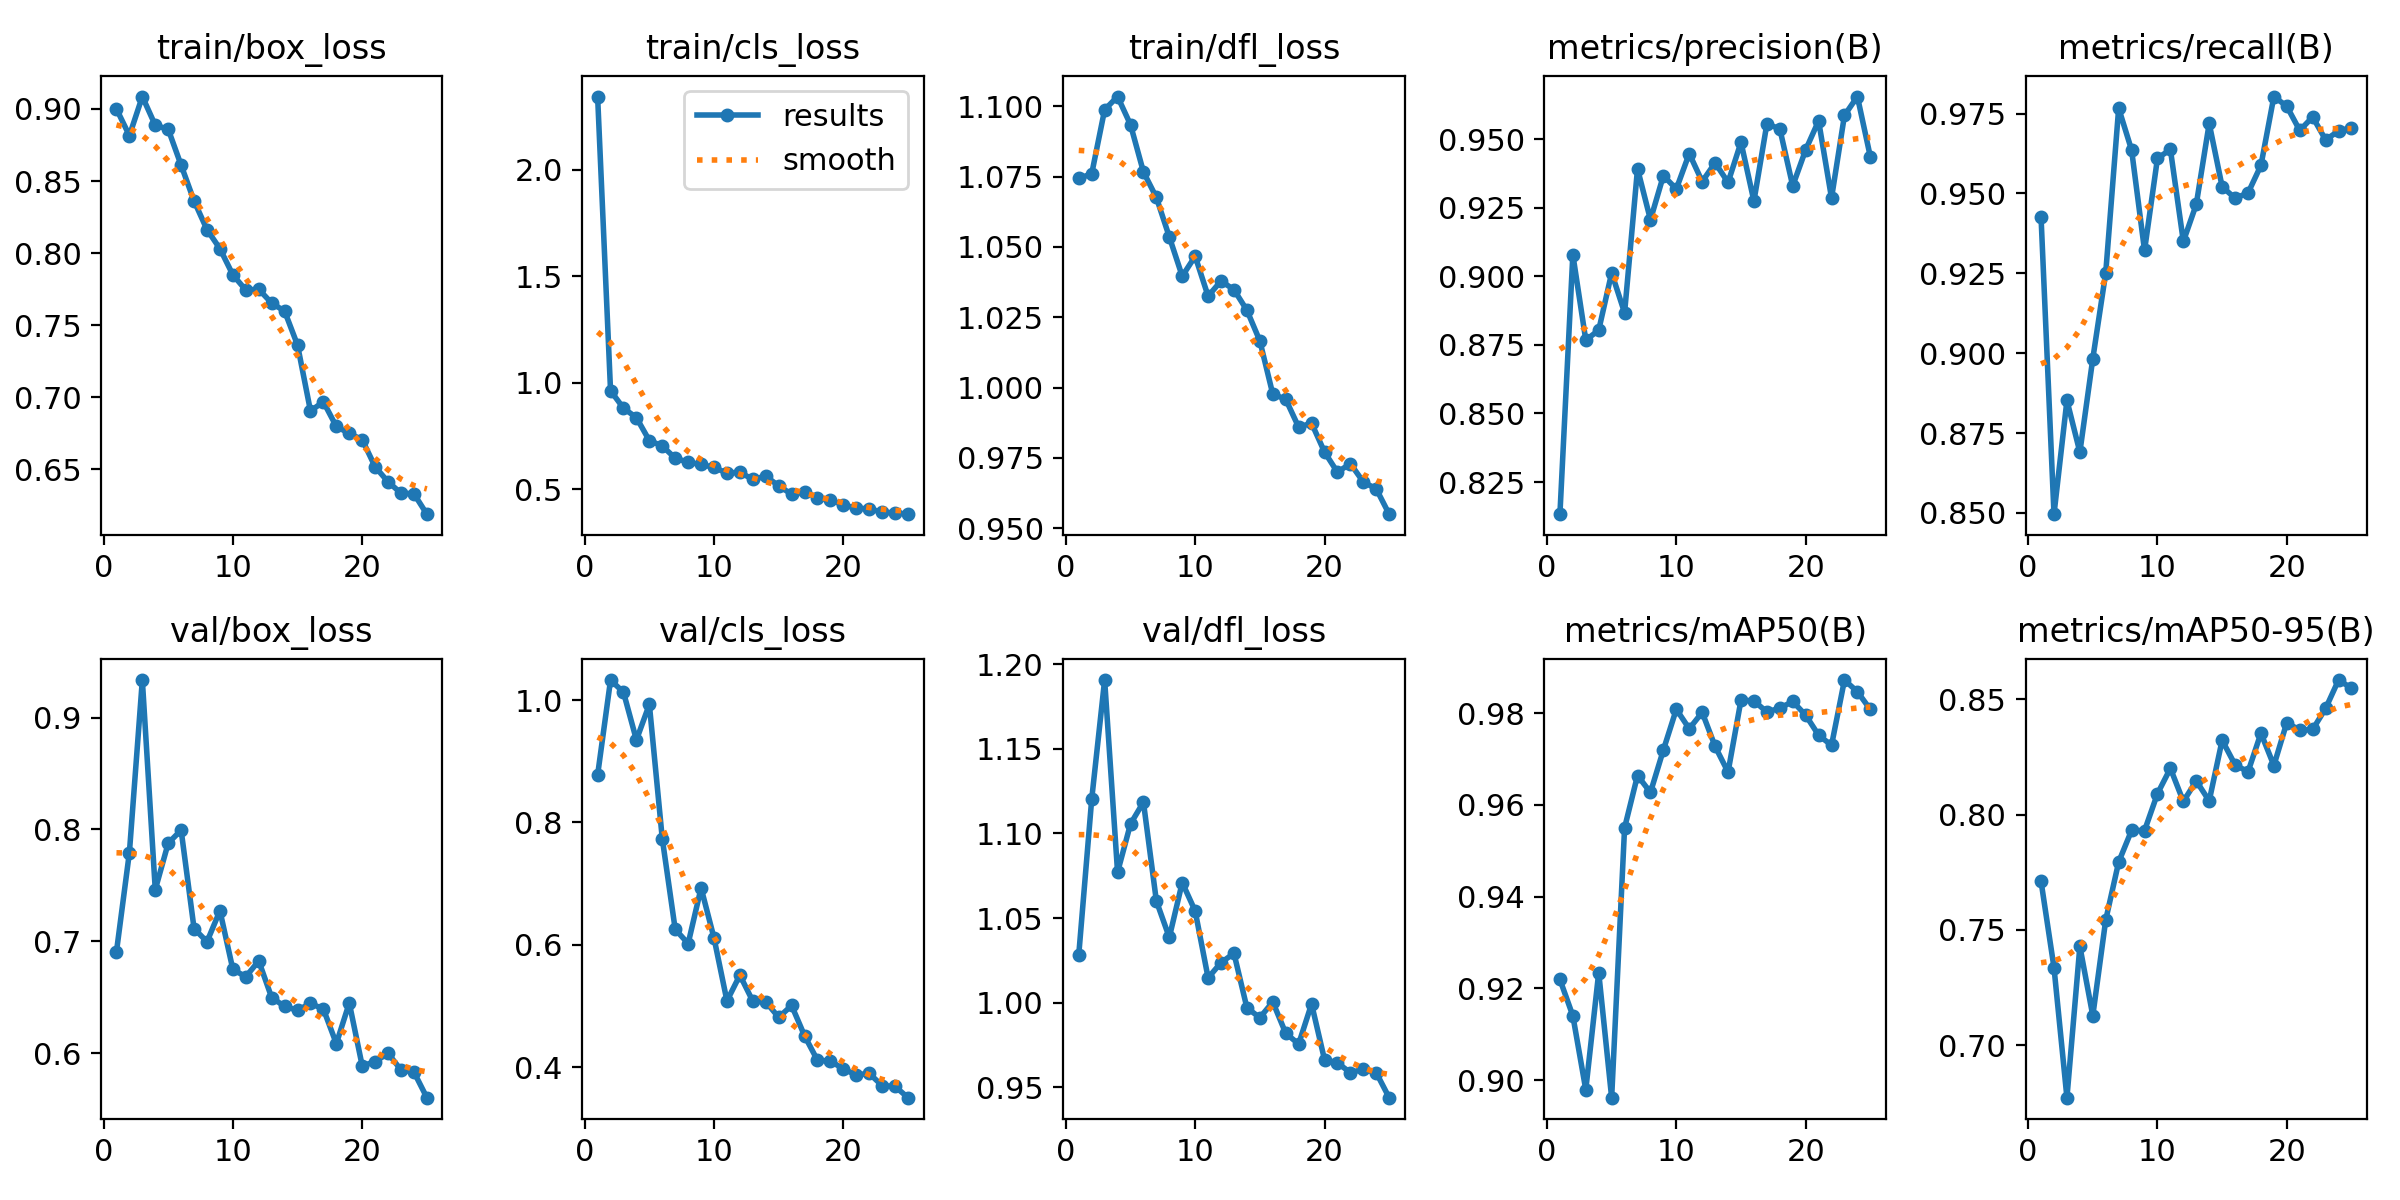

In [ ]:
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)

Bu grafikte YOLOv8 modelinin eğitim süreci boyunca elde edilen kayıp (loss) ve başarım metrikleri gösterilmektedir.

**Loss Grafikleri:**

**train/box_loss ve val/box_loss**

Modelin bounding box konumlarını ne kadar doğru tahmin ettiğini gösterir.
Eğitim süresince bu kayıpların düzenli şekilde azalması modelin nesnelerin konumunu giderek daha iyi öğrendiğini göstermektedir.

**train/cls_loss ve val/cls_loss**

Nesnelerin doğru sınıfa atanma başarısını ifade eder.
Eğitim ve doğrulama kayıplarının birbirine yakın seyretmesi modelin overfitting yapmadığını göstermektedir.

**train/dfl_loss ve val/dfl_loss**

Bounding box hassasiyetini artırmaya yönelik kullanılan Distribution Focal Loss değerleridir.
Bu kayıpların düşmesi kutu tahminlerinin daha hassas hale geldiğini göstermektedir.

Genel olarak loss grafiklerinin istikrarlı bir şekilde düşmesi modelin başarılı bir şekilde eğitildiğini göstermektedir.

**Precision, Recall ve mAP Metrikleri:**

Precision modelin tespit ettiği nesnelerin ne kadarının gerçekten doğru olduğunu gösterir. Eğitim ilerledikçe precision değerinin yükselmesi yanlış pozitif tahminlerin azaldığını ifade eder.

Recall gerçek nesnelerin ne kadarının model tarafından yakalanabildiğini gösterir. Recall değerinin artması modelin nesneleri kaçırma oranının azaldığını gösterir.

mAP@0.5 ve mAP@0.5:0.95
Modelin genel nesne tespit performansını ölçen en önemli metriklerdir.
Epoch ilerledikçe mAP değerlerinin artması modelin hem konum hem de sınıflandırma açısından başarılı olduğunu göstermektedir.

Genel Değerlendirme:

Eğitim ve doğrulama metrikleri paralel ilerlemiştir.

Overfitting gözlemlenmemiştir.

Model yaklaşık ilk epochlardan sonra hızlı bir öğrenme göstermiş ilerleyen epochlarda performans artışı daha stabil hale gelmiş.

Sonuç olarak:  
Elde edilen sonuçlara göre YOLOv8s modelinin verilen veri seti üzerinde eğitim sürecini yüksek doğrulukla tamamlamış.

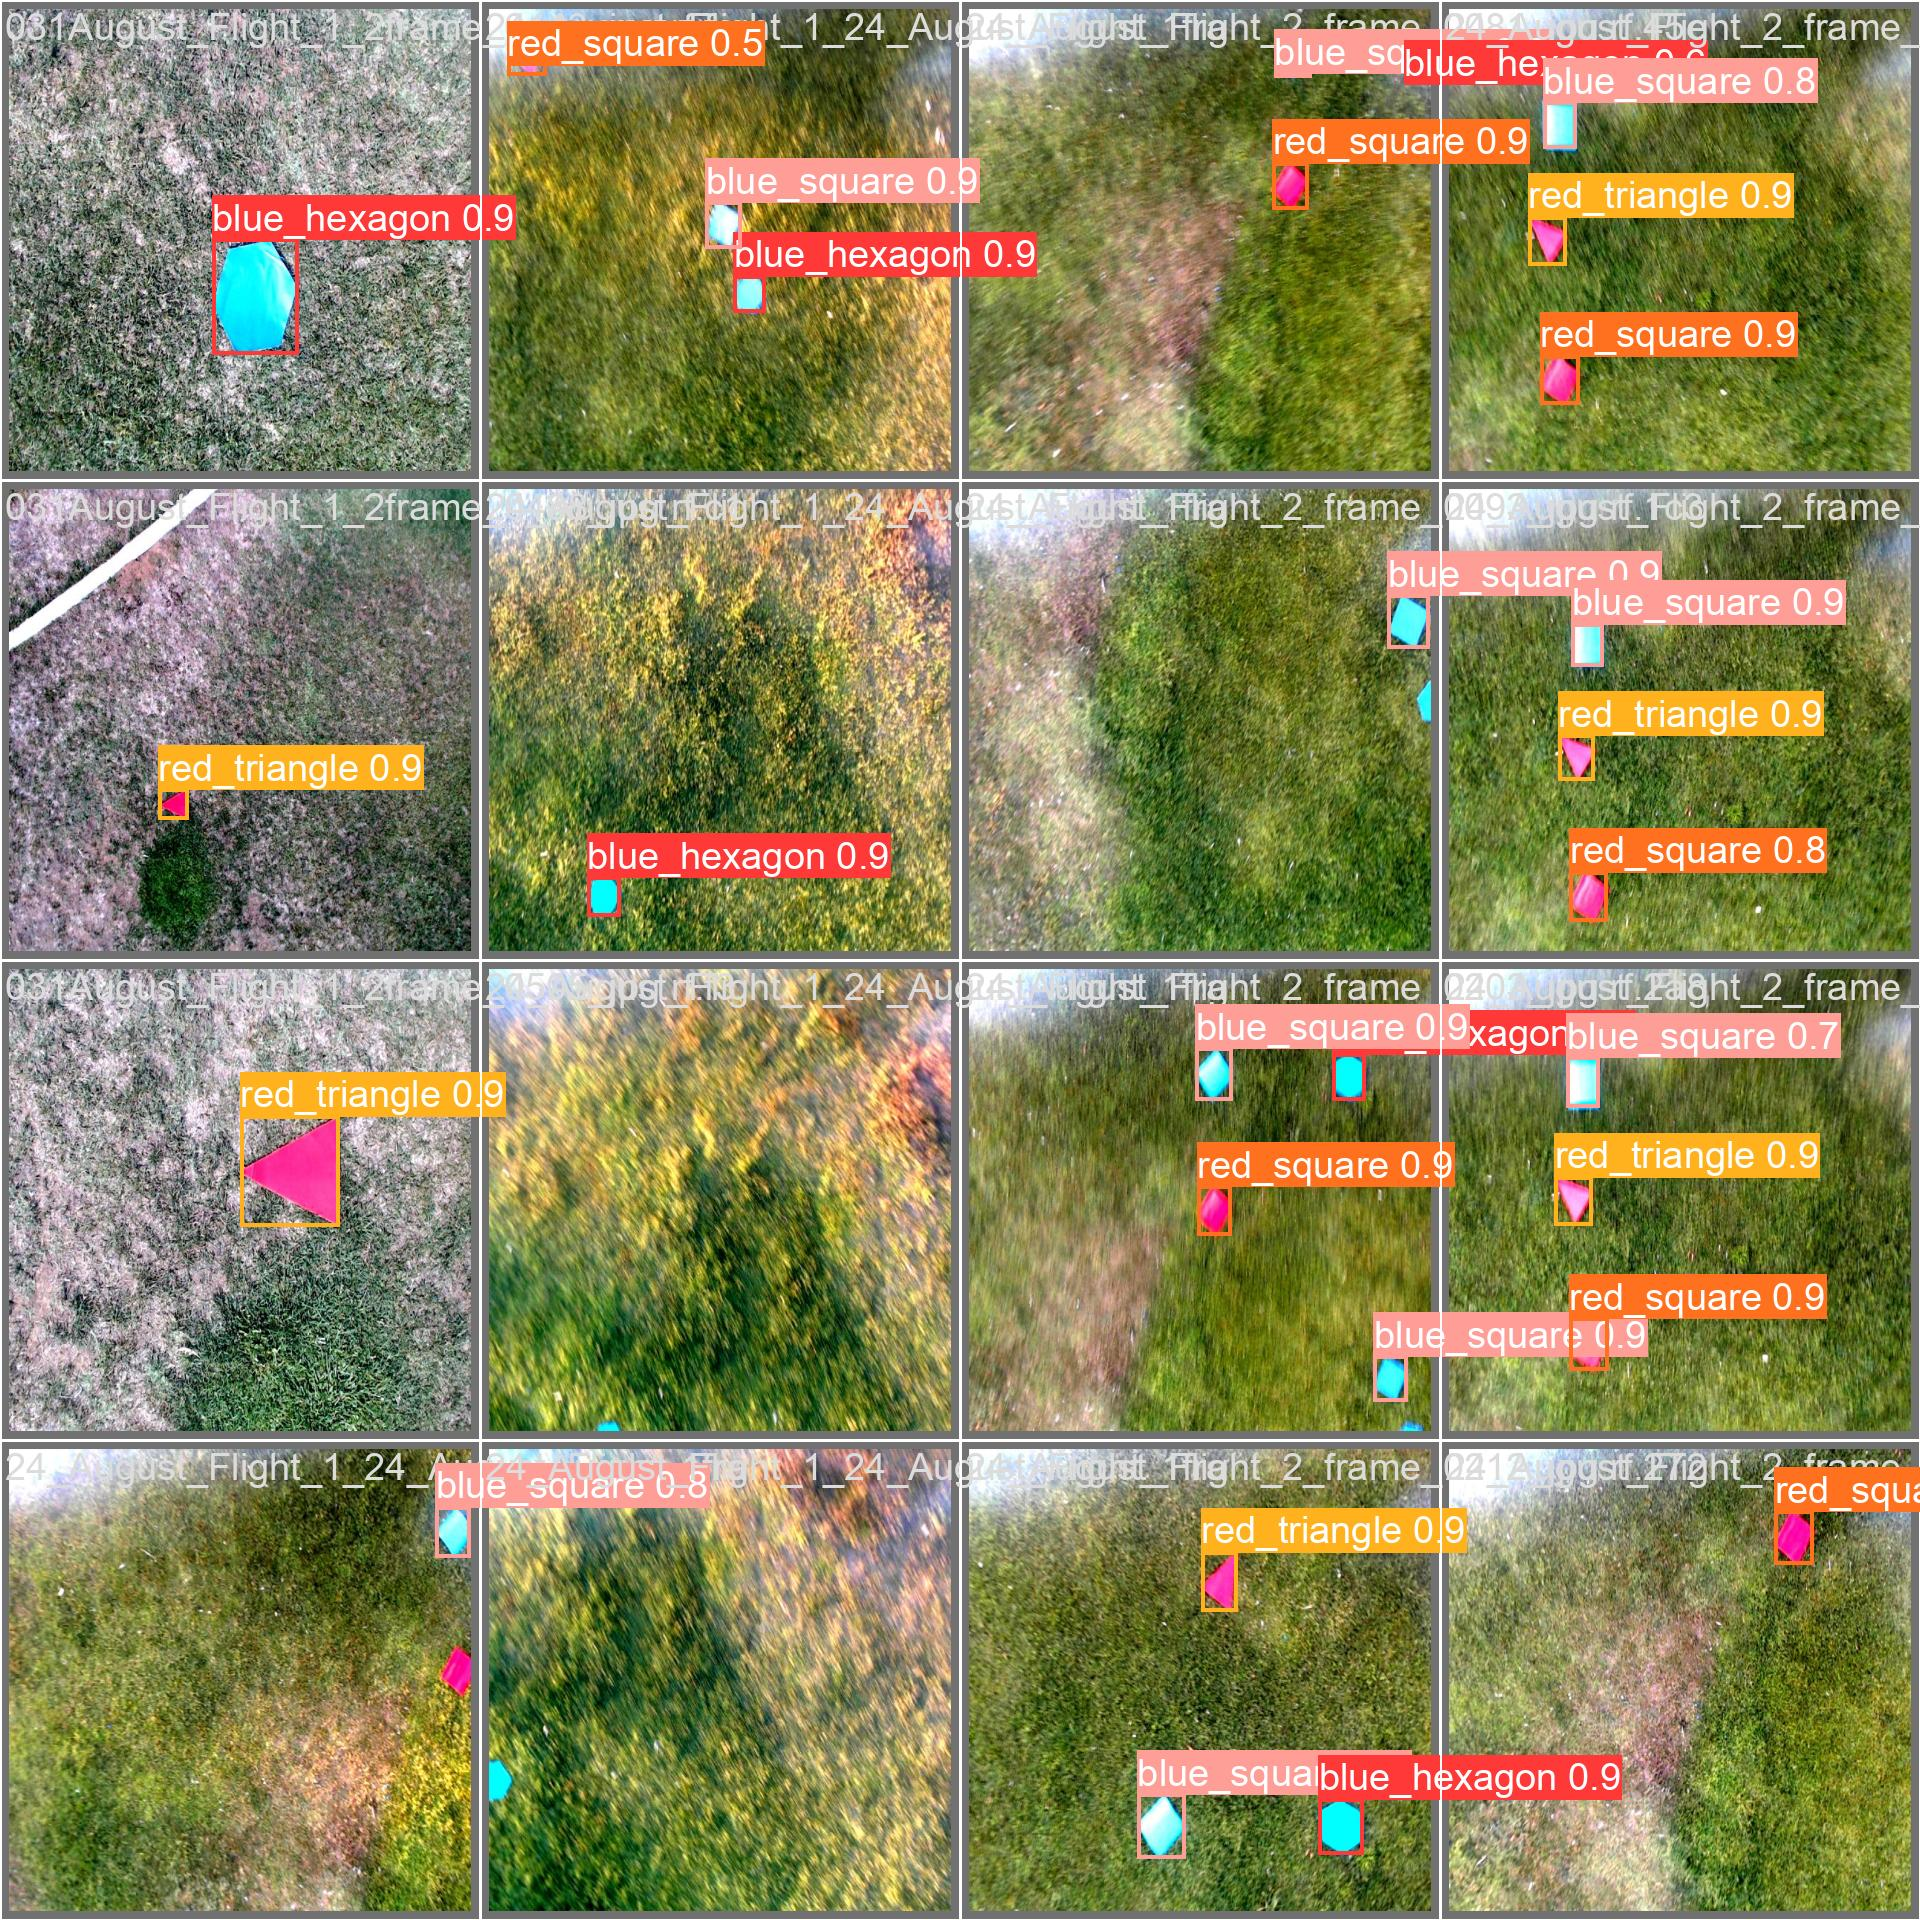

In [ ]:
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

Bu görsel, eğitilen YOLOv8 modelinin validation veri setinden rastgele seçilen bir görüntü üzerinde yaptığı nesne tespiti sonuçlarını gösteriyor.

Görüntü üzerinde:

Tespit edilen nesneler bounding box ile işaretlenmiştir.

Her kutunun üzerinde ilgili nesnenin sınıf adı ve güven skoru (confidence) yer almaktadır.

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py:567: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(file, map_location='cpu'), file  # load


In [ ]:
!ls /content/runs/detect/train/weights

best.pt  last.pt


Bu kod eğitimden sonra kaydedilen model dosyaları hangileri diye görmek için

In [ ]:
!yolo task=detect mode=val model=/content/runs/detect/train/weights/best.pt data=/content/datasets/data.yaml

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py:567: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(file, map_location='cpu'), file  # load


`task=detect`

Yapılacak görevin nesne tespiti (object detection) olduğunu söyler.

`mode=val`

Modeli doğrulama (validation) modunda çalıştırır.

`model=/content/runs/detect/train/weights/best.pt`

Eğitim sırasında kaydedilen en iyi model ağırlıkları kullanılır.

`data=/content/datasets/data.yaml`

Veri setine ait bilgileri içeren dosyadır.

Model hangi görüntüleri kullanacağını buradan öğrenir.

Sonuçlar modelin:

Nesneleri büyük oranda doğru tespit ettiğini, yanlış pozitif ve kaçırılan nesne sayısının çok düşük olduğunu genel performansının yüksek seviyede olduğunu gösteriyor.